____
# COMPUTE GRADIENT, INTERPOLATE AND ROTATE SWOT DATA ON COLOC POINTS

In [2]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

___________
# CHOOSE

In [1]:
# TO CHOOSE 
#L4_extent = 'regional_europe'
L4_extent = 'global'
drifters_sources = 'all_med_variational_10min_v0.nc'
spectral_decomp = True
#dt = '12h' #'nearestswath'
dt = '10d'
if spectral_decomp == True : drifters_sources = 'spectral_decomp_'+ drifters_sources
colocs_sources = f'{dt}_'+drifters_sources

In [3]:
ggd_variables = ['adt', 'sla', 'err_sla']

_______
# Data

In [4]:
dss = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc', 'L4_sealevel', f'L4_{L4_extent}_dt_2021_noswot.nc')).drop_vars(['lon_bnds', 'lat_bnds', 'nv'])
df = pd.read_csv(os.path.join(zarr_dir, 'drifters', f'drifterscoloc_'+colocs_sources.replace('.nc', '.csv')), dtype={'drifter_id':str}, parse_dates=['datetime'])

In [5]:
for ggd in ggd_variables :
    g = 9.81
    deglat_km = 111111 #m/deglat
    dlon_dx = 1/(deglat_km * np.cos(dss.latitude * np.pi / 180))
    dlat_dy = 1/deglat_km
    dss['ggde_'+ggd] = g*dss[ggd].differentiate('longitude')*dlon_dx
    dss['ggdn_'+ggd] = g*dss[ggd].differentiate('latitude')*dlat_dy
lon = df.longitude.values
lat = df.latitude.values
t = pd.to_datetime(df.datetime).values
ds0 = dss.interp(longitude=('z', lon), latitude=('z',lat), time= ('z',t))
df0 = ds0.to_dataframe()
df0.index.names = ['row_number']   
df0.to_csv(os.path.join(zarr_dir, 'alti',f'L4_{L4_extent}noswot_'+colocs_sources.replace('.nc', '.csv')))

In [13]:
dss.longitude.diff('longitude')

<xarray.DataArray 'longitude' (longitude: 27)> Size: 108B
array([0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25,
       0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25,
       0.25, 0.25, 0.25, 0.25, 0.25], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 108B 0.375 0.625 0.875 ... 6.375 6.625 6.875

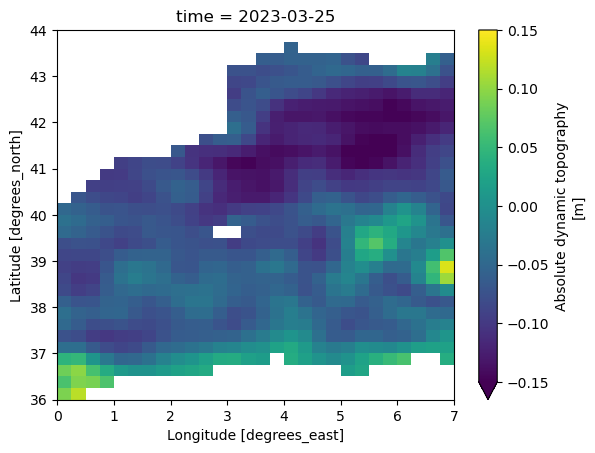

In [14]:
dss.isel(time=0).adt.plot(vmin=-0.15, vmax=0.15)

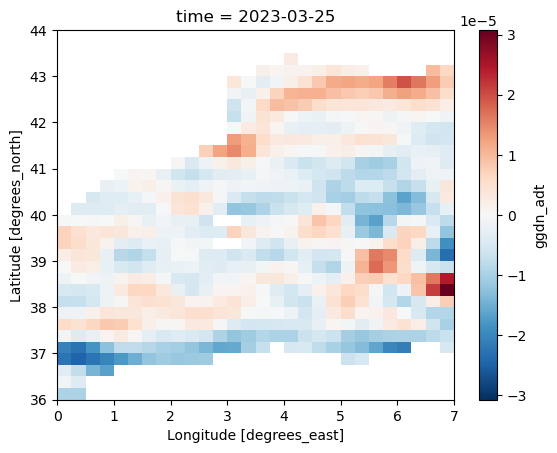

In [15]:
dss.isel(time=0).ggdn_adt.plot()

In [7]:
# TO CHOOSE 
L4_extent = 'regional_europe'
#L4_extent = 'global'
drifters_sources = 'all_med_variational_10min_v0.nc'
spectral_decomp = True
#dt = '12h' #'nearestswath'
dt='10d'
if spectral_decomp == True : drifters_sources = 'spectral_decomp_'+ drifters_sources
colocs_sources = f'{dt}_'+drifters_sources
ggd_variables = ['adt', 'sla', 'err_sla']

In [8]:
dss = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc', 'L4_sealevel', f'L4_with_swot.nc')).drop_vars(['lon_bnds', 'lat_bnds', 'nv'])
if spectral_decomp == True : drifters_sources = 'spectral_decomp_'+ drifters_sources
df = pd.read_csv(os.path.join(zarr_dir, 'drifters', f'drifterscoloc_'+colocs_sources.replace('.nc', '.csv')), dtype={'drifter_id':str}, parse_dates=['datetime'])

In [9]:
for ggd in ggd_variables :
    g = 9.81
    deglat_km = 111111 #m/deglat
    dlon_dx = 1/(deglat_km * np.cos(dss.latitude * np.pi / 180))
    dlat_dy = 1/deglat_km
    dss['ggde_'+ggd] = g*dss[ggd].differentiate('longitude')*dlon_dx
    dss['ggdn_'+ggd] = g*dss[ggd].differentiate('latitude')*dlat_dy
lon = df.longitude.values
lat = df.latitude.values
t = pd.to_datetime(df.datetime).values
ds0 = dss.interp(longitude=('z', lon), latitude=('z',lat), time= ('z',t))
df0 = ds0.to_dataframe()
df0.index.names = ['row_number']   
df0.to_csv(os.path.join(zarr_dir, 'alti',f'L4_withswot_'+colocs_sources.replace('.nc', '.csv')))

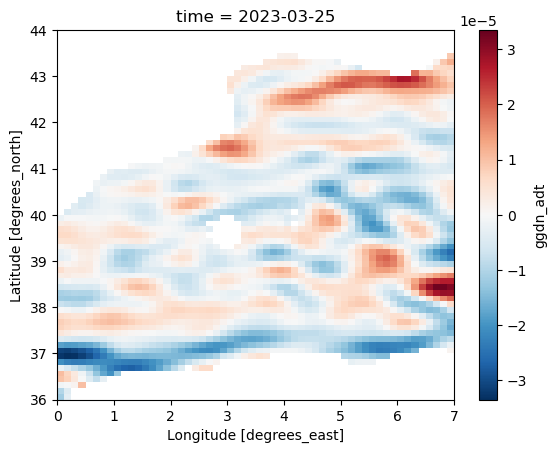

In [7]:
dss.isel(time=0).ggdn_adt.plot()